<div align="center">

# <span style="color: #3498db;">CA2 - MiniMax (Game) Algorithm</span>

**<span style="color:rgb(247, 169, 0);">[Student Name]</span> - <span style="color:rgb(143, 95, 195);">[Student Number]</span>**

</div>

# <span style="color: #3498db;">Checkers with Minimax Algorithm</span>

In this assignment, your tasks are as follows:

- Use a **pre-built Checkers game engine** (board, pieces, valid-move generation) and complete the TODOS we have put.
- Implement the **Minimax search algorithm**.
- Extend Minimax with **Alpha–Beta pruning**.
- And also, experiment with the **evaluation function** to fine tune the AI's playing style to make it as good as possible. (different heuristics)

In [1]:
import time
import pygame
import matplotlib.pyplot as plt

from copy import deepcopy

RED = (255,0,0)
WHITE = (255, 255, 255)

FPS = 60


pygame 2.6.1 (SDL 2.28.4, Python 3.13.5)
Hello from the pygame community. https://www.pygame.org/contribute.html


# <span style="color: #126ca8; font-size:32px;">Actual Game Implementation</span>

In [ ]:
# MAKE SURE TO ALSO COMPLETE THE TODO PARTS IN THE GAME IMPLEMENTATION SECTION.

WIDTH, HEIGHT = 800, 800
ROWS, COLS = 8, 8
SQUARE_SIZE = WIDTH//COLS


RED = (255, 0, 0)
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
BLUE = (0, 0, 255)
GREY = (128,128,128)

CROWN = pygame.transform.scale(pygame.image.load('assets/crown.png'), (44, 25))

FPS = 60

WIN = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption('Checkers')

In [3]:
def get_row_col_from_mouse(pos):
    x, y = pos
    row = y // SQUARE_SIZE
    col = x // SQUARE_SIZE
    return row, col

In [4]:
class Piece:
    PADDING = 15
    OUTLINE = 2

    def __init__(self, row, col, color):
        self.row = row
        self.col = col
        self.color = color
        self.king = False
        self.x = 0
        self.y = 0
        self.calc_pos()

    def calc_pos(self):
        self.x = SQUARE_SIZE * self.col + SQUARE_SIZE // 2
        self.y = SQUARE_SIZE * self.row + SQUARE_SIZE // 2

    def make_king(self):
        self.king = True

    def draw(self, win):
        radius = SQUARE_SIZE//2 - self.PADDING
        pygame.draw.circle(win, GREY, (self.x, self.y), radius + self.OUTLINE)
        pygame.draw.circle(win, self.color, (self.x, self.y), radius)
        if self.king:
            win.blit(CROWN, (self.x - CROWN.get_width()//2, self.y - CROWN.get_height()//2))

    def move(self, row, col):
        self.row = row
        self.col = col
        self.calc_pos()

    def __repr__(self):
        return str(self.color)
    
    def clone(self):
        cloned_piece = Piece(self.row, self.col, self.color)
        cloned_piece.king = self.king
        cloned_piece.x = self.x
        cloned_piece.y = self.y
        return cloned_piece

In [5]:
class Board:
    def __init__(self):
        self.board = []
        self.red_left = self.white_left = 12
        self.red_kings = self.white_kings = 0
        self.create_board()

    def draw_squares(self, win):
        win.fill(BLACK)
        for row in range(ROWS):
            for col in range(row % 2, COLS, 2):
                pygame.draw.rect(win, RED, (row*SQUARE_SIZE, col *SQUARE_SIZE, SQUARE_SIZE, SQUARE_SIZE))

    def evaluate(self):
        """
        TODO:
        Evaluation from WHITE's perspective:
        > 0  => White is better
        < 0  => Red is better
        ~ 0  => Equal
        Students must experiment with different hueristics to improve the evaluation function.
        """
        # white_score = self.white_left + (self.white_kings * 1.5)
        # red_score = self.red_left + (self.red_kings * 1.5)
        
        # return white_score - red_score

        white_score = 0.0
        red_score = 0.0
        
        for row in range(ROWS):
            for col in range(COLS):
                piece = self.board[row][col]
                
                # Assuming 0 is used for empty squares
                if piece != 0: 
                    piece_value = 0.0
                    
                    # 1. Material Value (Kings are worth significantly more)
                    if piece.king:
                        piece_value += 2.0
                    else:
                        piece_value += 1.0
                        
                        # 2. Advancement (Encourage regular pieces to move toward the king row)
                        if piece.color == WHITE:
                            piece_value += (7 - row) * 0.05 
                        else: # RED
                            piece_value += row * 0.05
                            
                    # 3. Center Control (Controlling the middle of the board is advantageous)
                    if 2 <= row <= 5 and 2 <= col <= 5:
                        piece_value += 0.15
                        
                    # 4. Back-Row Defense (Keep pieces on the home row to stop opponent from making kings)
                    if piece.color == WHITE and row == 7:
                        piece_value += 0.2
                    elif piece.color == RED and row == 0:
                        piece_value += 0.2
                        
                    # 5. Edge Safety (Pieces on the left/right edges cannot be jumped)
                    if col == 0 or col == COLS - 1:
                        piece_value += 0.1
                    
                    if piece.color == WHITE:
                        white_score += piece_value
                    else:
                        red_score += piece_value
                        
        return white_score - red_score

    def get_all_pieces(self, color):
        pieces = []
        for row in self.board:
            for piece in row:
                if piece != 0 and piece.color == color:
                    pieces.append(piece)
        return pieces

    def move(self, piece, row, col):
        self.board[piece.row][piece.col], self.board[row][col] = self.board[row][col], self.board[piece.row][piece.col]
        piece.move(row, col)

        if row == ROWS - 1 or row == 0:
            piece.make_king()
            if piece.color == WHITE:
                self.white_kings += 1
            else:
                self.red_kings += 1 

    def get_piece(self, row, col):
        return self.board[row][col]

    def create_board(self):
        for row in range(ROWS):
            self.board.append([])
            for col in range(COLS):
                if col % 2 == ((row +  1) % 2):
                    if row < 3:
                        self.board[row].append(Piece(row, col, WHITE))
                    elif row > 4:
                        self.board[row].append(Piece(row, col, RED))
                    else:
                        self.board[row].append(0)
                else:
                    self.board[row].append(0)

    def draw(self, win):
        self.draw_squares(win)
        for row in range(ROWS):
            for col in range(COLS):
                piece = self.board[row][col]
                if piece != 0:
                    piece.draw(win)

    def remove(self, pieces):
        for piece in pieces:
            if piece:
                self.board[piece.row][piece.col] = 0

                if piece.color == RED:
                    self.red_left -= 1
                    if piece.king:
                        self.red_kings -= 1
                else:
                    self.white_left -= 1
                    if piece.king:
                        self.white_kings -= 1

    def winner(self):
        if self.red_left <= 0:
            return WHITE
        if self.white_left <= 0:
            return RED
        return None

    def get_valid_moves(self, piece):
        """
        Get all valid moves for a given piece as:
        { (row, col): [list of captured pieces] }.
        """
        moves = {}
        left = piece.col - 1
        right = piece.col + 1
        row = piece.row

        if piece.color == RED or piece.king:
            moves.update(self._traverse_left(row -1, max(row-3, -1), -1, piece.color, left))
            moves.update(self._traverse_right(row -1, max(row-3, -1), -1, piece.color, right))
        if piece.color == WHITE or piece.king:
            moves.update(self._traverse_left(row +1, min(row+3, ROWS), 1, piece.color, left))
            moves.update(self._traverse_right(row +1, min(row+3, ROWS), 1, piece.color, right))

        return moves

    def _traverse_left(self, start, stop, step, color, left, skipped=[]):
        moves = {}
        last = []
        for r in range(start, stop, step):
            if left < 0:
                break

            current = self.board[r][left]
            if current == 0:
                if skipped and not last:
                    break
                elif skipped:
                    moves[(r, left)] = last + skipped
                else:
                    moves[(r, left)] = last

                if last:
                    if step == -1:
                        row = max(r-3, 0)
                    else:
                        row = min(r+3, ROWS)
                    moves.update(self._traverse_left(r+step, row, step, color, left-1,skipped=last))
                    moves.update(self._traverse_right(r+step, row, step, color, left+1,skipped=last))
                break
            elif current.color == color:
                break
            else:
                last = [current]

            left -= 1

        return moves

    def _traverse_right(self, start, stop, step, color, right, skipped=[]):
        moves = {}
        last = []
        for r in range(start, stop, step):
            if right >= COLS:
                break

            current = self.board[r][right]
            if current == 0:
                if skipped and not last:
                    break
                elif skipped:
                    moves[(r,right)] = last + skipped
                else:
                    moves[(r, right)] = last

                if last:
                    if step == -1:
                        row = max(r-3, 0)
                    else:
                        row = min(r+3, ROWS)
                    moves.update(self._traverse_left(r+step, row, step, color, right-1,skipped=last))
                    moves.update(self._traverse_right(r+step, row, step, color, right+1,skipped=last))
                break
            elif current.color == color:
                break
            else:
                last = [current]

            right += 1

        return moves
    
    def clone(self):
        cloned_board = Board()
        
        cloned_board.red_left = self.red_left
        cloned_board.white_left = self.white_left
        cloned_board.red_kings = self.red_kings
        cloned_board.white_kings = self.white_kings
        
        cloned_board.board = []
        for row in self.board:
            new_row = []
            for item in row:
                if item != 0:
                    new_row.append(item.clone())
                else:
                    new_row.append(0)
            cloned_board.board.append(new_row)
            
        return cloned_board


In [6]:
class Game:
    def __init__(self, win):
        self._init()
        self.win = win

    def update(self):
        self.board.draw(self.win)
        self.draw_valid_moves(self.valid_moves)
        pygame.display.update()

    def _init(self):
        self.selected = None
        self.board = Board()
        self.turn = RED
        self.valid_moves = {}

    def winner(self):
        piece_winner = self.board.winner()
        if piece_winner is not None:
            return piece_winner

        moves = 0
        for p in self.board.get_all_pieces(self.turn):
            moves += len(self.board.get_valid_moves(p))

        if moves == 0:
            return WHITE if self.turn == RED else RED

        return None

    def reset(self):
        self._init()

    def select(self, row, col):
        if self.selected:
            result = self._move(row, col)
            if not result:
                self.selected = None
                self.select(row, col)

        piece = self.board.get_piece(row, col)
        if piece != 0 and piece.color == self.turn:
            self.selected = piece
            self.valid_moves = self.board.get_valid_moves(piece)
            return True

        return False

    def _move(self, row, col):
        piece = self.board.get_piece(row, col)

        if self.selected and piece == 0 and (row, col) in self.valid_moves:
            self.board.move(self.selected, row, col)
            skipped = self.valid_moves[(row, col)]

            if skipped:
                self.board.remove(skipped)

                new_moves = self.board.get_valid_moves(self.selected)
                jump_moves = {m: s for m, s in new_moves.items() if s}

                if jump_moves:
                    self.valid_moves = jump_moves
                    return True

            self.change_turn()

        else:
            return False

        return True

    def draw_valid_moves(self, moves):
        for move in moves:
            row, col = move
            pygame.draw.circle(self.win, BLUE, (col * SQUARE_SIZE + SQUARE_SIZE//2, row * SQUARE_SIZE + SQUARE_SIZE//2), 15)

    def change_turn(self):
        self.valid_moves = {}
        if self.turn == RED:
            self.turn = WHITE
        else:
            self.turn = RED

    def get_board(self):
        return self.board

    def ai_move(self, board):
        self.board = board
        self.change_turn()

# <span style="color: #126ca8; font-size:32px;">Minimax AI Implementation</span>

In [7]:
# Helper functions for use in the Minimax implementation

def simulate_move(piece, move, board, skip):
    """
    Simulate moving a piece to a new position on a cloned board.
    Handles captures if they exist.
    """
    row, col = move
    board.move(piece, row, col)

    if skip:
        board.remove(skip)

    return board


def get_all_moves(board, color):
    """
    Generate all possible next board states for the given color.
    """
    moves = []

    for piece in board.get_all_pieces(color):
        valid_moves = board.get_valid_moves(piece)

        for move, skip in valid_moves.items():
            # Clone the board to avoid modifying the original
            temp_board = board.clone()

            # Get the corresponding piece from the cloned board
            temp_piece = temp_board.get_piece(piece.row, piece.col)

            # Simulate the move
            new_board = simulate_move(temp_piece, move, temp_board, skip)

            moves.append(new_board)

    return moves


# <span style="color: #126ca8; font-size:32px;">Base (No Alpha/Beta Pruning)</span>

In [ ]:


def minimax(board, depth, max_player: bool):
    global NODES_SEEN
    NODES_SEEN += 1

    # Terminal condition
    if depth == 0 or board.winner() is not None:
        return board.evaluate(), board

    if max_player:
        return _maximize(board, depth)
    else:
        return _minimize(board, depth)


def _maximize(board, depth):
    best_score = float("-inf")
    best_state = None

    for next_state in get_all_moves(board, WHITE):
        score, _ = minimax(next_state, depth - 1, False)

        if score > best_score:
            best_score = score
            best_state = next_state

    return best_score, best_state


def _minimize(board, depth):
    best_score = float("inf")
    best_state = None

    for next_state in get_all_moves(board, RED):
        score, _ = minimax(next_state, depth - 1, True)

        if score < best_score:
            best_score = score
            best_state = next_state

    return best_score, best_state


# <span style="color: #126ca8; font-size:32px;">Optimized Version (With Alpha/Beta Pruning)</span>

In [ ]:


def minimax_alpha_beta(position, depth, alpha, beta, max_player: bool):
    global NODES_SEEN
    NODES_SEEN += 1

    
    if depth == 0 or position.winner() is not None:
        return position.evaluate(), position

    if max_player:
        max_eval = float("-inf")
        best_move = None

        for move in get_all_moves(position, WHITE):
            evaluation, _ = minimax_alpha_beta(move, depth - 1, alpha, beta, False)

            if evaluation > max_eval:
                max_eval = evaluation
                best_move = move

            alpha = max(alpha, evaluation)

           
            if alpha >= beta:
                break

        return max_eval, best_move

    else:
        min_eval = float("inf")
        best_move = None

        for move in get_all_moves(position, RED):
            evaluation, _ = minimax_alpha_beta(move, depth - 1, alpha, beta, True)

            if evaluation < min_eval:
                min_eval = evaluation
                best_move = move

            beta = min(beta, evaluation)

   
            if alpha >= beta:
                break

        return min_eval, best_move


In [ ]:

def play_ai_vs_ai(search_depth=4, use_pruning=True, track_nodes=False):
    """
    Plays a full Checkers game: WHITE AI vs RED AI.
    Returns:
        winner_color -> WHITE, RED, or None
        moves_count  -> number of half-moves
        elapsed_time -> total game time (seconds)
    """

    board = Board()
    turn = RED
    moves_count = 0
    max_moves = 300

    if track_nodes:
        global NODES_SEEN
        NODES_SEEN = 0

    start_time = time.time()

    while True:

        winner = board.winner()
        if winner is not None:
            elapsed = time.time() - start_time
            return winner, moves_count, elapsed

        all_moves = get_all_moves(board, turn)

        if not all_moves:
            elapsed = time.time() - start_time
            winner = WHITE if turn == RED else RED
            return winner, moves_count, elapsed

        if use_pruning:
            _, best_board = minimax_alpha_beta(
                position=board,
                depth=search_depth,
                alpha=float('-inf'),
                beta=float('inf'),
                max_player=(turn == WHITE)
            )
        else:
            _, best_board = minimax(
                board,
                search_depth,
                (turn == WHITE)
            )

        if best_board is None:
            best_board = all_moves[0]

        board = best_board
        moves_count += 1
        turn = WHITE if turn == RED else RED

        if moves_count >= max_moves:
            elapsed = time.time() - start_time
            return None, moves_count, elapsed



def print_checkers_results(results, depth, pruning, total_time, avg_moves, avg_nodes):

    print(f"--- Depth: {depth} | Pruning: {pruning} ---")
    print(f"Games Played: {len(results)}")

    avg_time = total_time / len(results)
    print(f"Total Time: {total_time:.2f}s | Avg Time/Game: {avg_time:.2f}s")
    print(f"Average Moves: {avg_moves:.1f} | Average Nodes Searched: {avg_nodes:.1f}")

    white_wins = results.count(WHITE)
    red_wins = results.count(RED)
    draws = results.count(None)

    print(f"Results -> WHITE: {white_wins}, RED: {red_wins}, DRAWS/STUCK: {draws}\n")




def check_checkers_results(max_depth=3, games_per_setting=5):

    for use_pruning in [False, True]:
        for depth in range(1, max_depth + 1):

            results = []
            total_moves = 0
            total_time = 0
            total_nodes = 0

            for _ in range(games_per_setting):

                winner, moves, elapsed = play_ai_vs_ai(
                    search_depth=depth,
                    use_pruning=use_pruning,
                    track_nodes=True
                )

                results.append(winner)
                total_moves += moves
                total_time += elapsed
                total_nodes += NODES_SEEN

            avg_moves = total_moves / games_per_setting
            avg_nodes = total_nodes / games_per_setting

            print_checkers_results(
                results,
                depth,
                use_pruning,
                total_time,
                avg_moves,
                avg_nodes
            )




def run_analysis_for_plots(max_depth=4, games_per_setting=5):

    import matplotlib.pyplot as plt
    import numpy as np

    depths = list(range(1, max_depth + 1))

    time_minimax = []
    time_alphabeta = []
    nodes_minimax = []
    nodes_alphabeta = []

    for depth in depths:

       
        total_time = 0
        total_nodes = 0

        for _ in range(games_per_setting):
            global NODES_SEEN
            NODES_SEEN = 0

            _, _, elapsed = play_ai_vs_ai(
                search_depth=depth,
                use_pruning=False,
                track_nodes=True
            )

            total_time += elapsed
            total_nodes += NODES_SEEN

        time_minimax.append(total_time / games_per_setting)
        nodes_minimax.append(total_nodes / games_per_setting)

       
        total_time = 0
        total_nodes = 0

        for _ in range(games_per_setting):
            NODES_SEEN = 0

            _, _, elapsed = play_ai_vs_ai(
                search_depth=depth,
                use_pruning=True,
                track_nodes=True
            )

            total_time += elapsed
            total_nodes += NODES_SEEN

        time_alphabeta.append(total_time / games_per_setting)
        nodes_alphabeta.append(total_nodes / games_per_setting)

   

    def apply_gradient(ax):
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        ax.imshow(
            np.linspace(0, 1, 256).reshape(1, -1),
            extent=[xmin, xmax, ymin, ymax],
            aspect='auto',
            cmap="RdPu",
            alpha=0.06
        )

    pink = "#ff4fa3"
    green = "#38c485"

    plt.figure(figsize=(12, 5))
# ---- TIME PLOT ----
    ax1 = plt.subplot(1, 2, 1)
    plt.plot(depths, time_minimax, marker='o', linewidth=3,
             markersize=9, label='Minimax', color=green)
    plt.plot(depths, time_alphabeta, marker='s', linewidth=3,
             markersize=9, label='Alpha-Beta', color=pink)

    apply_gradient(ax1)

    plt.title('Average Time per Game vs Search Depth', fontsize=14, weight='bold')
    plt.xlabel('Search Depth d')
    plt.ylabel('Time (seconds)')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(framealpha=0.85)

    
    ax2 = plt.subplot(1, 2, 2)
    plt.plot(depths, nodes_minimax, marker='o', linewidth=3,
             markersize=9, label='Minimax', color=green)
    plt.plot(depths, nodes_alphabeta, marker='s', linewidth=3,
             markersize=9, label='Alpha-Beta', color=pink)

    apply_gradient(ax2)

    plt.title('Average Nodes Evaluated vs Search Depth', fontsize=14, weight='bold')
    plt.xlabel('Search Depth d')
    plt.ylabel('Number of Nodes N')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(framealpha=0.85)

    plt.tight_layout()
    plt.show()


# <span style="color: #126ca8; font-size:32px;">Main Game Loop</span>

--- Depth: 1 | Pruning: False ---
Games Played: 5
Total Time: 1.03s | Avg Time/Game: 0.21s
Average Moves: 300.0 | Average Nodes Searched: 2127.0
Results -> WHITE: 0, RED: 0, DRAWS/STUCK: 5

--- Depth: 2 | Pruning: False ---
Games Played: 5
Total Time: 1.43s | Avg Time/Game: 0.29s
Average Moves: 51.0 | Average Nodes Searched: 2966.0
Results -> WHITE: 0, RED: 5, DRAWS/STUCK: 0

--- Depth: 3 | Pruning: False ---
Games Played: 5
Total Time: 40.57s | Avg Time/Game: 8.11s
Average Moves: 300.0 | Average Nodes Searched: 126894.0
Results -> WHITE: 0, RED: 0, DRAWS/STUCK: 5

--- Depth: 4 | Pruning: False ---
Games Played: 5
Total Time: 49.62s | Avg Time/Game: 9.92s
Average Moves: 38.0 | Average Nodes Searched: 126041.0
Results -> WHITE: 5, RED: 0, DRAWS/STUCK: 0

--- Depth: 1 | Pruning: True ---
Games Played: 5
Total Time: 0.93s | Avg Time/Game: 0.19s
Average Moves: 300.0 | Average Nodes Searched: 2127.0
Results -> WHITE: 0, RED: 0, DRAWS/STUCK: 5

--- Depth: 2 | Pruning: True ---
Games Played: 

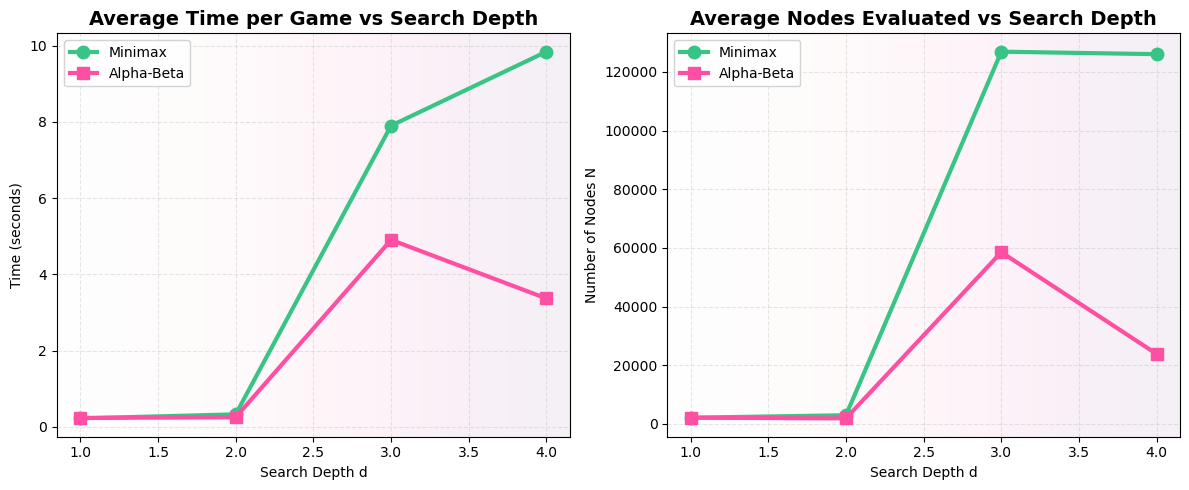

In [ ]:
run = True
clock = pygame.time.Clock()
game = Game(WIN)

# Experiment with this depth to evaluate performance
SEARCH_DEPTH = 4

# Run evaluation experiments
check_checkers_results(max_depth=4, games_per_setting=5)
run_analysis_for_plots()

while run:

    clock.tick(FPS)

  
   

    if game.turn == WHITE:

        _, new_board = minimax_alpha_beta(
            game.get_board(),
            depth=SEARCH_DEPTH,
            alpha=float("-inf"),
            beta=float("inf"),
            max_player=True
        )

        game.ai_move(new_board)


   
    winner = game.winner()
    if winner is not None:
        print("Winner:", "WHITE" if winner == WHITE else "RED")
        run = False

   
    for event in pygame.event.get():
        

        if event.type == pygame.QUIT:
            run = False

        elif event.type == pygame.MOUSEBUTTONDOWN:
            pos = pygame.mouse.get_pos()
            row, col = get_row_col_from_mouse(pos)
            game.select(row, col)

    
    game.update()

pygame.quit()


In [ ]:
#1. In your minimax implementation, what evaluation function did you use, and on what basis does it assign a value to each board state?
# In my implementation of the Checkers AI, the evaluation function assigns a numerical score to a board state based on several key factors that influence the strength of a position. The evaluation is primarily based on:

# the number of regular pieces the player has
# the number of king pieces the player has
# the difference between the player’s and opponent’s total score
# the strategic value of pieces (kings are worth more)
# A typical evaluation formula we used is:


# score = (white_pieces + 2 * white_kings) - (red_pieces + 2 * red_kings)
# This means:

# having more pieces increases your score
# having more kings, which are more powerful, increases your score even more
# the function returns a positive number if White is winning, negative if Red is winning
# This evaluation is sufficient for a basic Checkers AI because it directly reflects material advantage, which is strongly correlated with winning potential.

In [ ]:
# 2. Is it possible to reorder the children of each node so that the most promising moves are evaluated first? If yes, explain how. If not, explain why it is not feasible.
# Yes, it is possible to reorder the children of a node so that more promising moves are evaluated first. One common method is to apply the evaluation function to each child board state immediately after generating it, and then sort the moves based on this evaluation before performing minimax or alpha-beta search.

# For example:

# if it is a maximizing player, sort children from highest score to lowest
# if it is a minimizing player, sort children from lowest score to highest
# This technique is beneficial because:

# in alpha-beta pruning, a better ordering leads to earlier cutoffs
# better ordering means many branches become unnecessary to explore
# This directly reduces the search time.

# If this reordering is not implemented, alpha-beta still works, but it becomes less efficient and results in fewer pruned branches.

In [ ]:
# 3. Explain the term “branching factor” and how it affects the performance of the game tree search.
# The branching factor refers to the average number of possible moves (children) available at each state of the game tree.

# In Checkers, the branching factor can vary but is often between 5 and 15 depending on the position.

# A higher branching factor means:

# the game tree grows exponentially faster
# the minimax algorithm becomes slower
# deeper search becomes harder
# In general, the time complexity of minimax is:
# O(b^d)
# where
# b = branching factor
# d = depth
# Therefore, reducing the branching factor or pruning unnecessary branches significantly improves performance.



In [12]:
# 4. Explain why alpha-beta pruning allows the algorithm to run faster without losing accuracy.
# Alpha-beta pruning eliminates branches of the game tree that cannot possibly affect the outcome of the minimax decision. In other words, if it becomes clear that a particular move is worse than a previously explored move, the algorithm stops exploring that branch.

# The key point is:

# alpha-beta does not approximate or change the minimax result
# it simply avoids evaluating moves that would never be selected
# Thus:

# the final decision remains exactly the same as pure minimax
# the search becomes dramatically faster
# many game states never need to be evaluated
# This is why alpha-beta pruning both preserves correctness and increases efficiency.

In [13]:
# 5. Why is using pure minimax not optimal when the opponent plays randomly? What alternative algorithm could work better in this situation?
# Pure minimax assumes that:

# the opponent always plays optimally
# the opponent always chooses the move that minimizes your score
# However, if the opponent plays randomly or non-optimally, minimax overestimates the opponent’s strength. This leads to unnecessary defensive play or conservative decisions.

# An alternative approach that often performs better in such situations is:

# Expectiminimax (expectation-maximization)

# This algorithm replaces the opponent’s minimizing step with an average (expected value) over all possible random moves. It models the opponent as a probabilistic player instead of an optimal one.

# This makes expectiminimax more suitable when:

# the opponent behaves unpredictably
# the opponent is not rational
# randomness is part of the game
# Other alternatives include:

# Monte Carlo Tree Search (MCTS)
# Reinforcement Learning evaluation functions
# stochastic policies
# But expectiminimax is the closest direct extension of minimax for random behavior.

In [ ]:
# 5. Why Minimax Is Not Optimal Against a Random Opponent, and a Better Alternative
# Short Answer
# Minimax assumes an optimal opponent and behaves overly conservatively against random play. A better replacement is the Expectiminimax algorithm.

# Full Explanation
# Minimax models the opponent as a perfectly rational actor who always selects the move that minimizes the player’s advantage. However, when the opponent plays randomly or unpredictably, this core assumption becomes invalid. As a result, minimax makes decisions based on worst‑case scenarios that never occur, leading to overly defensive or inefficient play.

# A more appropriate approach in the presence of randomness is Expectiminimax, which incorporates chance nodes into the search tree. These nodes compute the expected value of all possible opponent moves instead of the minimum value. As a result, the algorithm evaluates situations based on realistic probabilistic outcomes rather than worst‑case behavior.

# Other potential alternatives include Monte Carlo Tree Search (MCTS) or reinforcement-learning-based evaluation functions, but expectiminimax is the most direct minimax-compatible solution.